# Shear Column

![](img/frame-1022.png)

In [1]:
from xara_prism import CantileverColumn, BasicShape, PlotPoint, check_span
from xara_prism.loading import AxialForce
from xara_prism.solutions.reissner_terminal import ReissnerTerminalCantilever

import numpy as np

In [2]:
import thesis

In [3]:
b = 6
d = 12
E = 29e3
Iy = b*d**3/12
A = 1e3
G = 11e3

# A = b*d
# nu = 0.3
# G = E/(2*(1+nu))

# Ay = A*5/6

In [4]:

I = Iy

shape = BasicShape(
    E=E,
    G=G,
    A=A,
    Ay=A,
    Az=A,
    Iy=I,
    Iz=I,
    J =I*2
)

L = 120
Pref = E*Iy*np.pi**2/(L*2)**2

column = CantileverColumn(length=L, shape=shape, shear=1, smax=1.5, loads=[
    AxialForce(-Pref, x=L, scale="linear", offset=-L/40, follower=False),
])

## Solution

(0.0, 1.5)

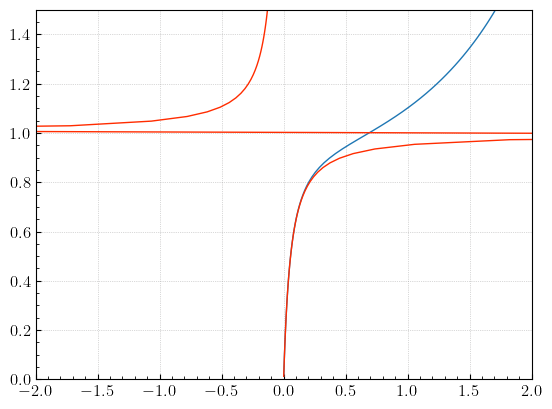

In [5]:

sol_exact = ReissnerTerminalCantilever(column)

steps = 80
time = np.linspace(1/steps, column.smax, steps)

p = PlotPoint(column, x="r_plan", y="time", time=time, loc=L)
p.add(sol_exact)
p.add(column.solution("pdelta"))
p.ax.set_xlim([-2, 2]);
p.ax.set_ylim([0, column.smax])

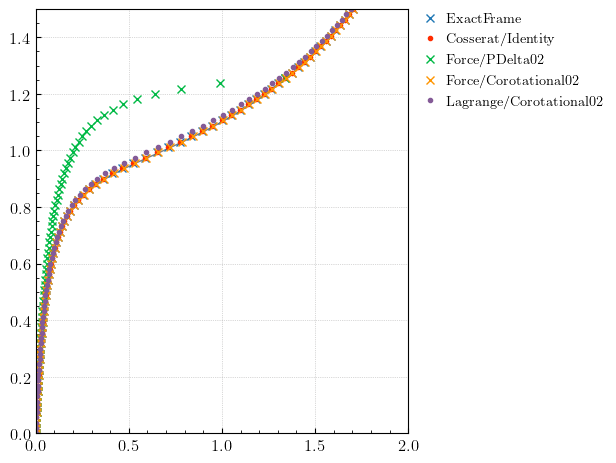

In [ ]:
analysis_options = dict(test=("Energy", 1e-14, 10, 0))

p = PlotPoint(column, x="r_plan", y="time", time=time, loc=L)
p.add(sol_exact, color="gray")

p.add(
    column.analyze(3, "ExactFrame", "Linear", ne=8, steps=steps, 
                   loading_options=dict(point_basis="local"),
                   analysis_options=analysis_options,
    ),
    marker="x",
    ls="None",
    label="ExactFrame"
)

p.add(
    column.analyze(3, "CosseratFrame", "Identity", ne=8, steps=steps, 
                   loading_options=dict(point_basis="local"),
                   analysis_options=analysis_options,
    ),
    marker=".",
    ls="None",
    label="Cosserat/Identity"
)


p.add(
    column.analyze(3, "ForceFrame", "PDelta02", ne=8, steps=steps, 
                   loading_options=dict(point_basis="local"),
                   analysis_options=analysis_options,
    ),
    marker="x",
    ls="None",
    label="Force/PDelta02"
)

p.add(
    column.analyze(3, "ForceFrame", "Corotational02", ne=8, steps=steps, 
                   loading_options=dict(point_basis="local"),
                   analysis_options=analysis_options,
    ),
    marker="x",
    ls="None",
    label="Force/Corotational02"
)

p.add(
    column.analyze(3, "LagrangeFrame", "Corotational02", ne=4, steps=steps,
                   loading_options=dict(point_basis="local"),
                   analysis_options=analysis_options,
    ),
    marker=".",
    ls="None",
    label="Lagrange/Corotational02"
)


p.ax.set_xlim([0, 2])
p.ax.set_ylim([0, column.smax])
thesis.legend(p.ax)

In [7]:
check_span(
    column.analyze(3, "ExactFrame", "Linear", ne=8, steps=steps, 
                   loading_options=dict(point_basis="local"),
                #    analysis_options=dict(test=("Energy", 1e-10, 20, 2)),
                   analysis_options=dict(test=("NormDispIncr", 1e-12, 100, 0))
    ),
    sol_exact,
    time=1.5
)

check_span(
    column.analyze(3, "ForceFrame", "Corotational03", ne=8, steps=steps, 
                   loading_options=dict(point_basis="local"),
                #    analysis_options=dict(test=("Energy", 1e-10, 20, 2)),
                   analysis_options=dict(test=("NormDispIncr", 1e-12, 150, 0))
    ),
    sol_exact,
    time=None, #1.5
)

AnalysisOutput(ExactFrame/Linear, ne=8, nen=2) ReissnerTerminalCantilever(shear=1)
  time      x │ u_long_out   u_long_sol         diff │ u_tran_out   u_tran_sol         diff
──────      ─ │ ──────────   ──────────   ───────────┼ ──────────   ──────────   ──────────
 1.500
            0 │     0.0000       0.0000    0.000e+00 │     0.0000      -0.0000    0.000e+00 │       6
           15 │    -0.2424      -0.3267   -2.579e-01 │    -2.6674      -2.6794   -4.465e-03 │       6
           30 │    -2.2771      -2.4616   -7.494e-02 │   -10.2050     -10.2458   -3.977e-03 │       6
           45 │    -7.3385      -7.6444   -4.001e-02 │   -21.4370     -21.5082   -3.310e-03 │       6
           60 │   -15.8610     -16.3035   -2.715e-02 │   -34.9647     -35.0559   -2.601e-03 │       6
           75 │   -27.5902     -28.1753   -2.077e-02 │   -49.6030     -49.6999   -1.949e-03 │       6
           90 │   -41.8584     -42.5848   -1.706e-02 │   -64.5850     -64.6754   -1.398e-03 │       6
          10

In [8]:
check_span(
    column.analyze(3, "ForceFrame", "Corotational02", ne=4, steps=20, 
                   loading_options=dict(point_basis="local"),
                   analysis_options=dict(test=("NormDispIncr", 1e-12, 150, 0))
    ),
    sol_exact,
    time=1.5
)

AnalysisOutput(ForceFrame/Corotational02, ne=4, nen=2) ReissnerTerminalCantilever(shear=1)
  time      x │ u_long_out   u_long_sol         diff │ u_tran_out   u_tran_sol         diff
──────      ─ │ ──────────   ──────────   ───────────┼ ──────────   ──────────   ──────────
 1.500
            0 │     0.0000       0.0000    0.000e+00 │     0.0000      -0.0000    0.000e+00 │       7
           30 │    -1.8422      -2.4616   -2.516e-01 │   -10.3326     -10.2458    8.477e-03 │       7
           60 │   -15.2099     -16.3035   -6.708e-02 │   -35.2955     -35.0559    6.834e-03 │       7
           90 │   -41.1319     -42.5848   -3.412e-02 │   -65.0161     -64.6754    5.268e-03 │       7
          120 │   -73.8786     -75.6351   -2.322e-02 │   -94.8907     -94.5039    4.093e-03 │       7

